# 01: Preprocessing

## Preliminary Setup

In [15]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.depuration import *

In [2]:
# Open data files
train_raw = pd.read_csv("data/train.csv")
test_raw = pd.read_csv("data/test.csv")

## Data Cleaning & Exploration

In [3]:
train_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [4]:
# Target: SalePrice
y_train = train_raw[["Id", "SalePrice"]]

In [5]:
y_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Id         1460 non-null   int64
 1   SalePrice  1460 non-null   int64
dtypes: int64(2)
memory usage: 22.9 KB


In [6]:
test_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1455 non-null   str    
 3   LotFrontage    1232 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   str    
 6   Alley          107 non-null    str    
 7   LotShape       1459 non-null   str    
 8   LandContour    1459 non-null   str    
 9   Utilities      1457 non-null   str    
 10  LotConfig      1459 non-null   str    
 11  LandSlope      1459 non-null   str    
 12  Neighborhood   1459 non-null   str    
 13  Condition1     1459 non-null   str    
 14  Condition2     1459 non-null   str    
 15  BldgType       1459 non-null   str    
 16  HouseStyle     1459 non-null   str    
 17  OverallQual    1459 non-null   int64  
 18  OverallCond    1459

In [7]:
# Almacenar los Ids de test y la longitud del train para separar después
ids_test = test_raw['Id']
len_train = len(train_raw)

# Mergar train y test para preprocesar juntos
merged_df = pd.concat([train_raw, test_raw], axis=0).reset_index(drop=True)

In [8]:
merged_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             2919 non-null   int64  
 1   MSSubClass     2919 non-null   int64  
 2   MSZoning       2915 non-null   str    
 3   LotFrontage    2433 non-null   float64
 4   LotArea        2919 non-null   int64  
 5   Street         2919 non-null   str    
 6   Alley          198 non-null    str    
 7   LotShape       2919 non-null   str    
 8   LandContour    2919 non-null   str    
 9   Utilities      2917 non-null   str    
 10  LotConfig      2919 non-null   str    
 11  LandSlope      2919 non-null   str    
 12  Neighborhood   2919 non-null   str    
 13  Condition1     2919 non-null   str    
 14  Condition2     2919 non-null   str    
 15  BldgType       2919 non-null   str    
 16  HouseStyle     2919 non-null   str    
 17  OverallQual    2919 non-null   int64  
 18  OverallCond    2919

In [9]:
# Quitar Id y variable objetivo del dataset para preprocesar solo las features
merged_df.drop(["Id", "SalePrice"], axis = 1, inplace=True)

In [10]:
# Separar columnas numéricas y categóricas
# Valores únicos por columna numérica
merged_df.select_dtypes(np.number).nunique().sort_values()

HalfBath            3
BsmtHalfBath        3
KitchenAbvGr        4
BsmtFullBath        4
Fireplaces          5
FullBath            5
YrSold              5
GarageCars          6
BedroomAbvGr        8
OverallCond         9
OverallQual        10
MoSold             12
TotRmsAbvGrd       14
PoolArea           14
MSSubClass         16
3SsnPorch          31
LowQualFinSF       36
MiscVal            38
YearRemodAdd       61
GarageYrBlt       103
YearBuilt         118
ScreenPorch       121
LotFrontage       128
EnclosedPorch     183
OpenPorchSF       252
BsmtFinSF2        272
WoodDeckSF        379
MasVnrArea        444
GarageArea        603
2ndFlrSF          635
BsmtFinSF1        991
TotalBsmtSF      1058
1stFlrSF         1083
BsmtUnfSF        1135
GrLivArea        1292
LotArea          1951
dtype: int64

In [11]:
# Seleccionar columnas numéricas
num_cols = merged_df.select_dtypes(include=["int64", "float64"]).columns

#  Seleccionar columnas categóricas: aquellas que se han forzado a ser categóricas y aquellas numéricas con pocos valores únicos
forced_categoricals = ["MSSubClass"]
auto_categoricals = [col for col in num_cols if merged_df[col].nunique() <=12]

# Mergear ambas listas de columnas categóricas y convertirlas a tipo 'category'
categorical_cols = sorted(set(forced_categoricals + auto_categoricals))
merged_df[categorical_cols] = merged_df[categorical_cols].astype("category")

# Agregar a la lista de columnas categóricas aquellas que son de tipo 'object'
categorical_cols.extend(merged_df.select_dtypes("object").columns)

# Actualizar columnas numéricas
num_cols = merged_df.select_dtypes(include=["int64", "float64"]).columns
print(f"Número de columnas categóricas: {len(categorical_cols)}"
      f"\nNúmero de columnas numéricas: {len(num_cols)}")

Número de columnas categóricas: 56
Número de columnas numéricas: 23


C:\Users\sebas\AppData\Local\Temp\ipykernel_8948\128818507.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols.extend(merged_df.select_dtypes("object").columns)


Columnas numéricas:

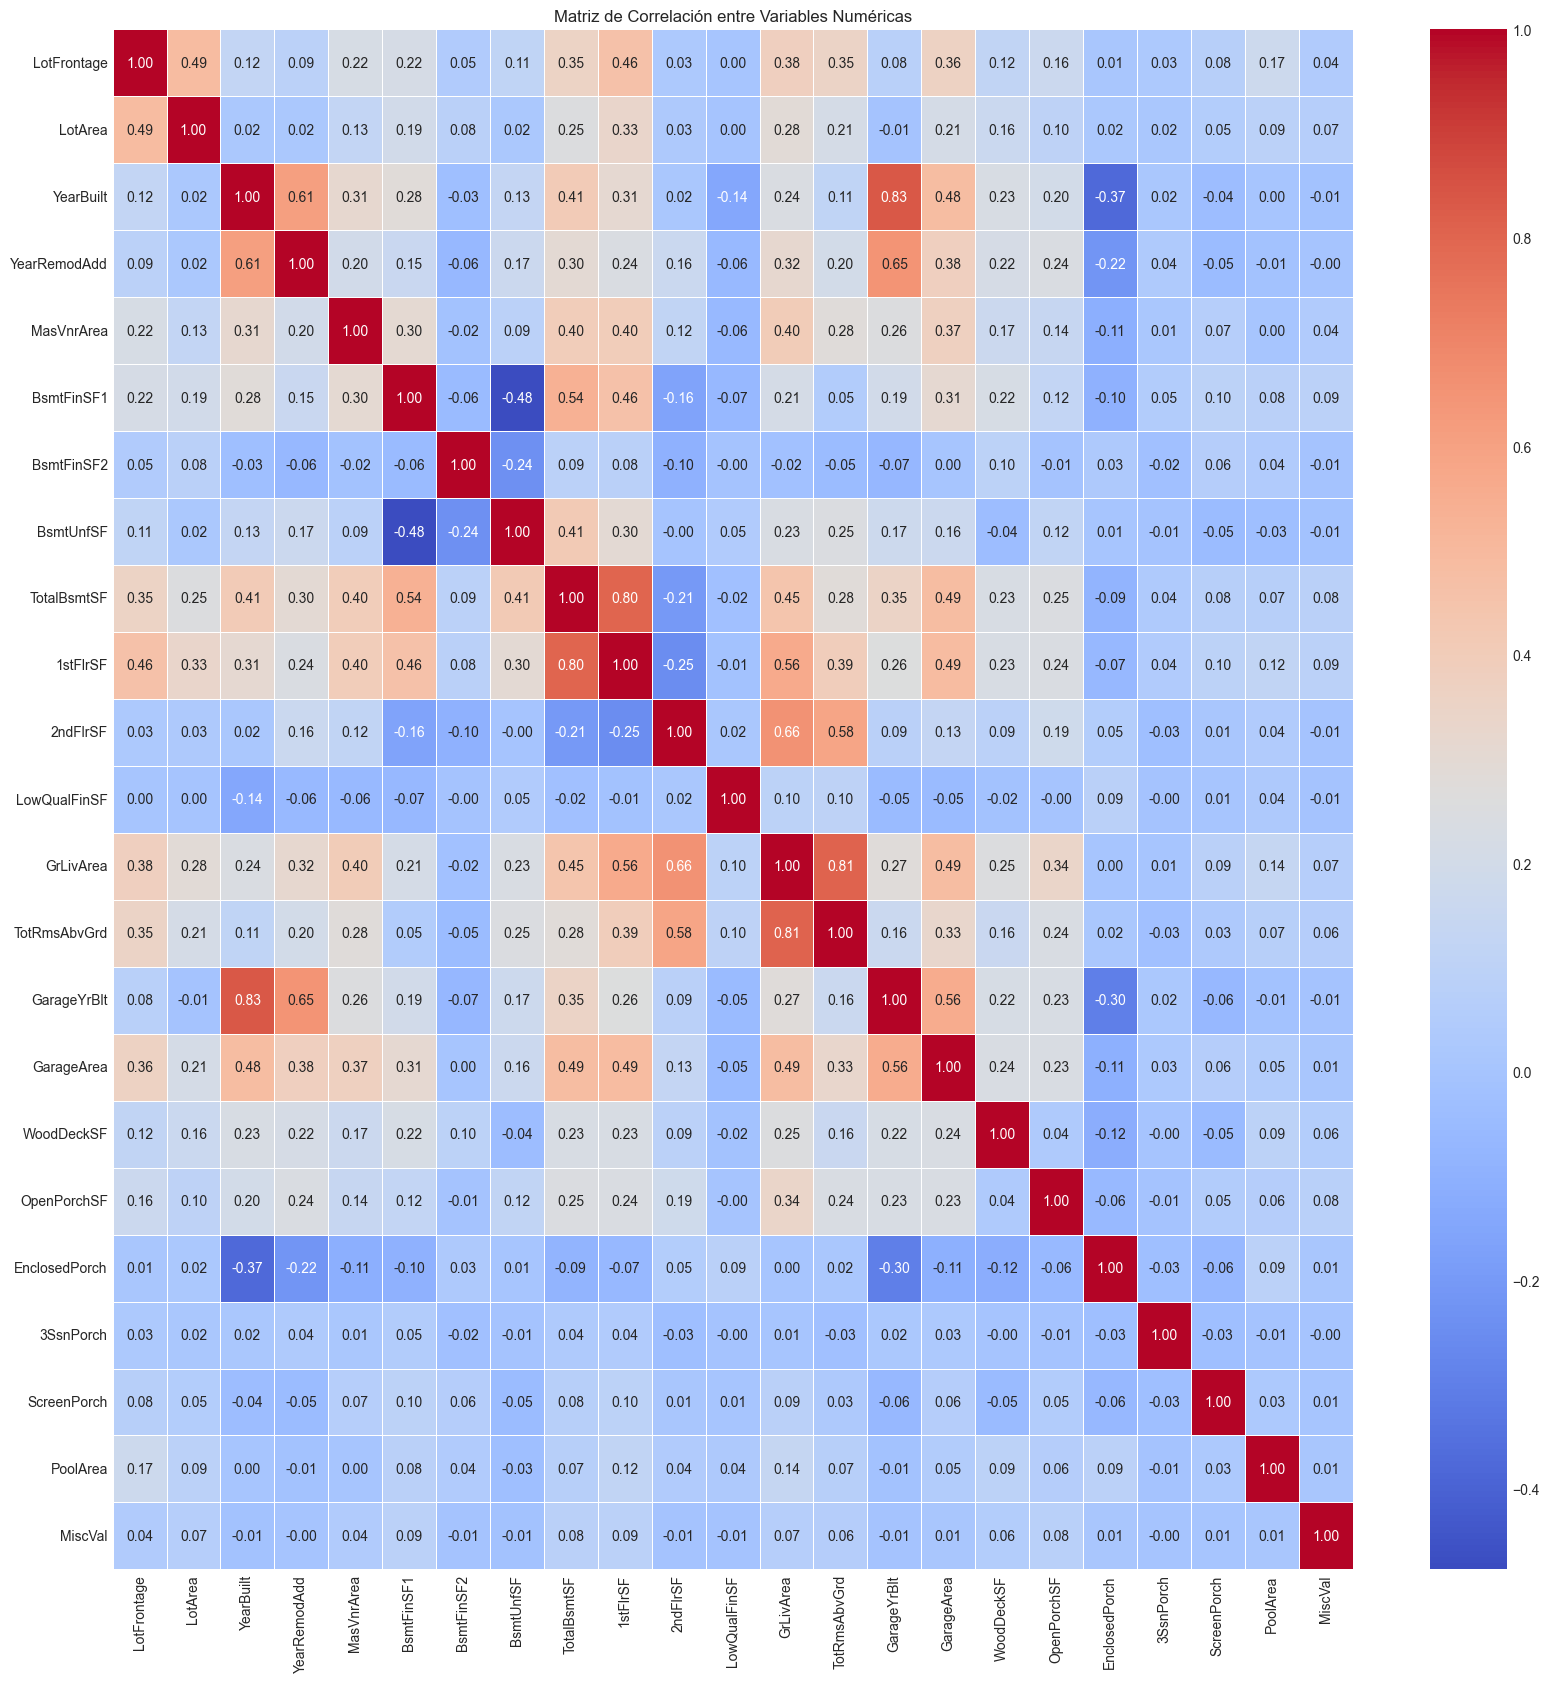

In [23]:
# Matriz de correlación entre variables numéricas
correlation_matrix = merged_df[num_cols].corr()
# Ampliar el tamaño de la figura para mejorar la legibilidad
plt.figure(figsize=(20, 20))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlación entre Variables Numéricas")

plt.show()

In [12]:
merged_df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
LotFrontage,2433.0,69.305795,23.344905,21.0,59.0,68.0,80.0,313.0
LotArea,2919.0,10168.114080,7886.996359,1300.0,7478.0,9453.0,11570.0,215245.0
YearBuilt,2919.0,1971.312778,30.291442,1872.0,1953.5,1973.0,2001.0,2010.0
YearRemodAdd,2919.0,1984.264474,20.894344,1950.0,1965.0,1993.0,2004.0,2010.0
MasVnrArea,2896.0,102.201312,179.334253,0.0,0.0,0.0,164.0,1600.0
BsmtFinSF1,2918.0,441.423235,455.610826,0.0,0.0,368.5,733.0,5644.0
BsmtFinSF2,2918.0,49.582248,169.205611,0.0,0.0,0.0,0.0,1526.0
BsmtUnfSF,2918.0,560.772104,439.543659,0.0,220.0,467.0,805.5,2336.0
TotalBsmtSF,2918.0,1051.777587,440.766258,0.0,793.0,989.5,1302.0,6110.0
1stFlrSF,2919.0,1159.581706,392.362079,334.0,876.0,1082.0,1387.5,5095.0


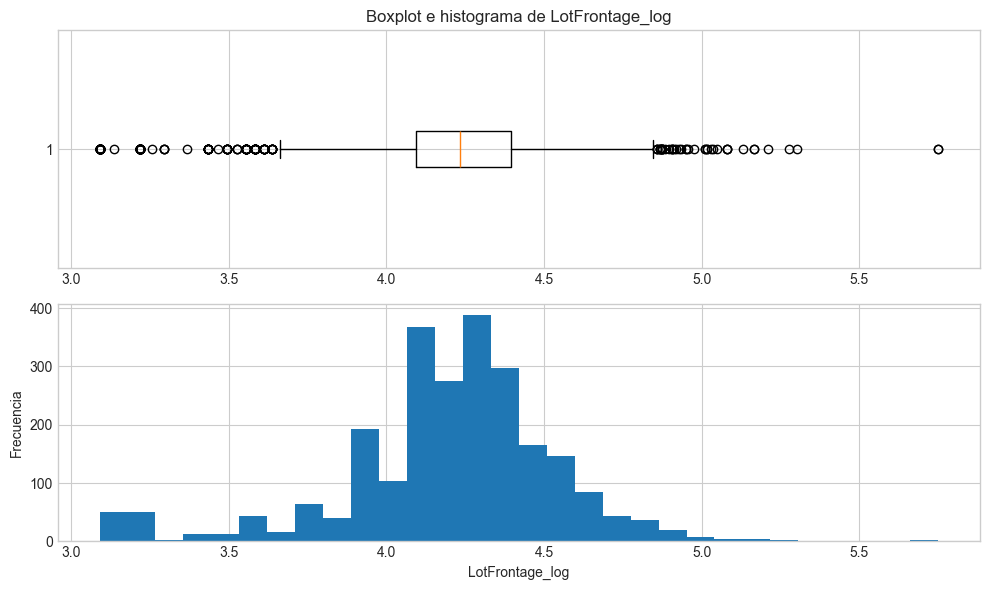

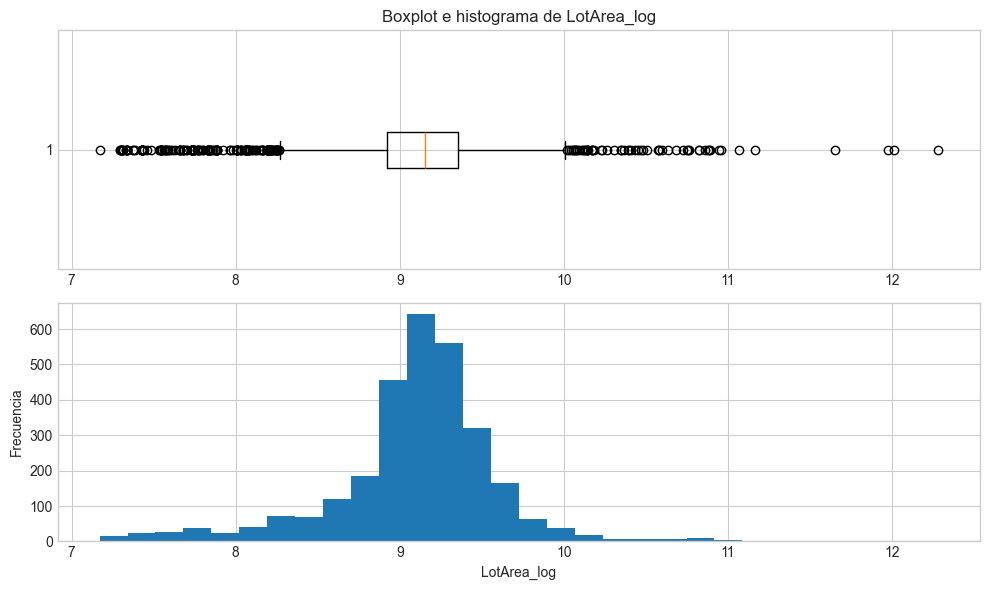

In [24]:
# Visualización de variables numéricas
variables_a_visualizar = ['LotFrontage', 'LotArea']
for variable in variables_a_visualizar:
    visualizar_variable(merged_df, variable, transformar='log')

* `LotFrontage`: Será reemplazada por la variable `LotDepthRatio` como el cociente de `LotArea` entre `LotFrontage`.
* `LotArea`: al aplicar transformación logarítmica la distribución se normaliza, pero permanecen un gran número de *outliers*, tanto superiores como inferiores. Ya que se aplicarán modelos basados en árboles de decisión, estos outliers no serán tratados ya que dichos modelos son inmunes a los valores atípicos.

Se imputan NaN de ambas variables por la mediana del vecindario (Neighborhood). 

In [ ]:
imputar_por_mediana = ['LotFrontage', 'LotArea']

Variables de sótano:
* `BsmtFinSF1`: Área terminada del sótano, tipo 1 (pies cuadrados)
* `BsmtFinSF2`: Área terminada del sótano, tipo 2 (pies cuadrados)
* `BsmtUnfSF`: Área no terminada del sótano (pies cuadrados)
* `TotalBsmtSF`: Área total del sótano (pies cuadrados)

Se reemplazarán las 3 primeras por una variable `RatioBsmt` como el porcentaje del sótano que está terminado, manteniendo `TotalBsmtSF`

In [28]:
imputar_por_cero = ['BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF']

Variables de plantas:
* `1stFlrSF` y  `2ndFlrSF`: estan correlacionadas con el tamaño total `GrLivArea`.
* `LowQualFinSF`: es una variable rara, mayormente cero. Se elimina del dataset.

Se reemplazan las primeras por la variable `has_second_floor`, manteniendo `GrLivArea`. 

In [ ]:
imputar_por_cero.extend(['1stFlrSF', '2ndFlrSF', 'GrLivArea'])
merged_df.drop(['LowQualFinSF'], axis=1, inplace=True)

* `MasVnrArea`: valores en cero son casas que no tienen revestimento de mampostería en la fachada. Interactua con la variable `MasVnrType`. Se imputan missings como cero.

In [29]:
imputar_por_cero.extend(['MasVnrArea'])

* `YearRemodAdd` el pico en 1950 es un valor missing no declarado. Se imputa a NaN y se crea la variable `YearRemodAdd_is_missing` para detectar si existen patrones en los valores perdidos. Será reemplazada por la variable `age` en la sección de Feature Engineering.

In [23]:
merged_df[merged_df['YearRemodAdd'] == 1950] = np.nan
merged_df['YearRemodAdd_is_missing'] = merged_df['YearRemodAdd'].isna().astype(int)


* `TotRmsAbvGrd`: tiene alta correlación con `GrLivArea`.

Se reemplaza por `AvgRoomSize`.

Variables de Garage
* `GarageYrBlt`: se imputan missings con 0, se reemplaza por `GarageAge`.
* `GarageArea`: esta relacionada con capacidad del Garage `GarageCars`. Se imputan missings por cero, se reemplazara por la variable binaria `HasGarage`.

In [ ]:
imputar_por_cero.extend(['GarageArea', 'GarageYrBlt'])

* `WoodDeckSF`: se imputan missings con cero. Se crea variable `HasWoodDeck`

In [ ]:
imputar_por_cero.extend(['WoodDeckSF'])

* `OpenPorchSF`: se crea variable `HasOpenPorch`.

In [ ]:
imputar_por_cero.extend(['OpenPorchSF'])

* `PoolArea`: se reemplaza por `HasPool`.

In [16]:
merged_df[num_cols].skew().sort_values()

YearBuilt        -0.600114
YearRemodAdd     -0.451252
GarageYrBlt      -0.382150
GarageArea        0.241301
TotRmsAbvGrd      0.758757
2ndFlrSF          0.862118
BsmtUnfSF         0.919824
TotalBsmtSF       1.162882
GrLivArea         1.270010
BsmtFinSF1        1.425722
1stFlrSF          1.470360
LotFrontage       1.503278
WoodDeckSF        1.843380
OpenPorchSF       2.536417
MasVnrArea        2.602589
ScreenPorch       3.948723
EnclosedPorch     4.005950
BsmtFinSF2        4.147456
3SsnPorch        11.381914
LowQualFinSF     12.094977
LotArea          12.829025
PoolArea         16.907017
MiscVal          21.958480
dtype: float64

In [17]:
# Separar variables numéricas simétricas de las asimétrricas para aplicar transformaciones diferentes
variables_simetricas, variables_asimetricas = separar_numericas(merged_df, num_cols)

In [15]:
merged_df[categorical_cols].describe().T

,count,unique,top,freq
BedroomAbvGr,2919,8,3,1596
BsmtFullBath,2917.0,4.0,0.0,1705.0
BsmtHalfBath,2917.0,3.0,0.0,2742.0
Fireplaces,2919,5,0,1420
FullBath,2919,5,2,1530
GarageCars,2918.0,6.0,2.0,1594.0
HalfBath,2919,3,0,1834
KitchenAbvGr,2919,4,1,2785
MSSubClass,2919,16,20,1079
MoSold,2919,12,6,503


## Imputar missings

In [26]:
# Incidencia de missings en numéricas
merged_df[num_cols].apply(lambda x: x.isna().sum() / len(x)).sort_values(ascending=False)


LotFrontage      0.278177
GarageYrBlt      0.161357
MasVnrArea       0.131552
GarageArea       0.124015
YearRemodAdd     0.123672
YearBuilt        0.123672
LotArea          0.123672
BsmtFinSF2       0.123672
BsmtFinSF1       0.123672
1stFlrSF         0.123672
BsmtUnfSF        0.123672
2ndFlrSF         0.123672
LowQualFinSF     0.123672
GrLivArea        0.123672
TotalBsmtSF      0.123672
TotRmsAbvGrd     0.123672
WoodDeckSF       0.123672
OpenPorchSF      0.123672
EnclosedPorch    0.123672
3SsnPorch        0.123672
ScreenPorch      0.123672
PoolArea         0.123672
MiscVal          0.123672
dtype: float64

* `MasVnrArea`: se imputan a cero

In [ ]:
merged_df['MasVnrArea'].replace(np.nan, 0, inplace=True)


## Feature Engineering

In [ ]:
# Crear variable age
merged_df['age'] = merged_df['YrSold'] - merged_df['YearBuilt']

In [ ]:
# Crear variable RatioBsmt
finished_area = merged_df['BsmtFinSF1'] + merged_df['BsmtFinSF2']
merged_df['RatioBsmt'] = np.where(merged_df['TotalBsmtSF'] != 0, finished_area / merged_df['TotalBsmtSF'], 0)

# Se eliminan las variables originales de sótano
merged_df.drop(['BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF'], axis=1, inplace=True)

In [ ]:
# Crear HasSecondFloor
merged_df['HasSecondFloor'] = (merged_df['2ndFlrSF'] > 0).astype(int)

# Se eliminan las variables originales de área
merged_df.drop(['1stFlrSF', '2ndFlrSF'], axis=1, inplace=True)

In [ ]:
# Crear AvgRoomSize
merged_df['AvgRoomSize'] = merged_df['GrLivArea'] / merged_df['TotRmsAbvGrd']

# Eliminar TotRmsAbvGrd
merged_df.drop(['TotRmsAbvGrd'], axis=1, inplace=True)

In [ ]:
# Crear HasGarage
merged_df['HasGarage'] = (merged_df['GarageArea'] > 0).astype(int)

# Eliminar GarageArea
merged_df.drop(['GarageArea'], axis=1, inplace=True)

In [ ]:
# Crear GarageAge
merged_df['GarageAge'] = merged_df['YrSold'] - merged_df['YearBuilt']

In [ ]:
# Crear HasWoodDeck
merged_df['HasWoodDeck'] = (merged_df['WoodDeckSF'] > 0).astype(int)